In [ ]:
from jax import grad, jit, vmap
from functools import partial
import jax
import jax.numpy as jnp
import numpy as np
import numpy.matlib
import time

import sklearn
import matplotlib.pyplot as plt

np.random.seed(seed=236)

## Intialize dataset

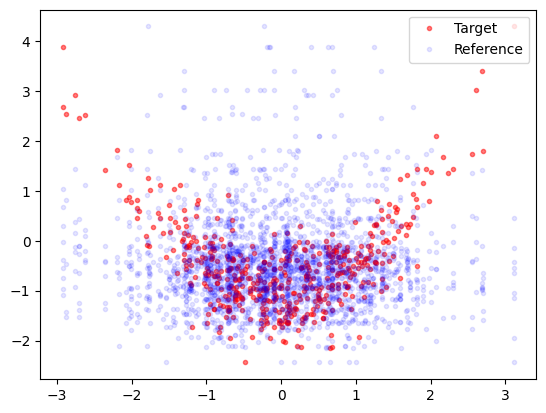

In [ ]:
N = 500
M = 5*N

# sample N times the actual "to be discovered" joint distribution
data = np.zeros([N,2])
for i in range(N):
    data[i,0] = np.random.randn()
    data[i,1] = 0.5*(np.random.randn() + data[i,0]**2) - 1

# create cartesian product of
# data[:,0] (i.e. samples of X) and data[:,1] (i.e. samples of Y)
data_product = np.transpose([np.tile(data[:,0], N), np.repeat(data[:,1], N)])
# and choose M elements
data_product_selection = data_product[np.random.choice(N**2, M, replace=False),:]

plt.plot(data[:,0], data[:,1], '.r', label='Target',alpha=0.5)
plt.plot(data_product_selection[:,0], data_product_selection[:,1], '.b', label='Reference',alpha=0.1)
plt.legend()
plt.show()

## Define kernels and vectorized operations

In [ ]:
# radial basis function kernel
kernel_rbf = lambda a, b: jnp.exp(-jnp.sum((a - b) ** 2))

# polynomoial kernel
kernel_polynomial = lambda a, b: (0.1*jnp.dot(a,b) + 1)**4

# sigmoid kernel
kernel_sig = lambda a, b, gamma=0.1, c=-2.0: jnp.tanh(gamma * jnp.dot(a, b.T) + c)

# linear kernel
kernel_linear = lambda a, b: jnp.dot(a, b)

def compute_cost_matrix(X, Y):
      distances = jnp.sum((X[:, None] - Y[None, :])**2, axis=-1)
      return distances

In [ ]:
# the gradient of the kernel w.r.t to the first argument
kernel_grad_p = jax.grad(kernel_polynomial, argnums=0)

# a vectorized version of the previous (so you can apply on components of the vector)
kernel_grad_vector_p = jax.vmap(kernel_grad_p)

# TODO
grad_Kvmap_p = jax.vmap(kernel_grad_p, in_axes=(0, None))
grad_Kvmap2_p = jax.vmap(grad_Kvmap_p, in_axes=(None, 0), out_axes=(2))

# approximate version of the gradient of rho_t - mu using a the kernel
# polyn: (p)
gradient_p = lambda data_current, data_target: jnp.mean(grad_Kvmap2_p(data_current, data_current),2) - jnp.mean(grad_Kvmap2_p(data_current, data_target),2)

In [ ]:
# the gradient of the kernel w.r.t to the first argument
kernel_grad_rbf = jax.grad(kernel_rbf, argnums=0)

# a vectorized version of the previous (so you can apply on components of the vector)
kernel_grad_vector_rbf = jax.vmap(kernel_grad_rbf)

# TODO
grad_Kvmap_rbf = jax.vmap(kernel_grad_rbf, in_axes=(0, None))
grad_Kvmap2_rbf = jax.vmap(grad_Kvmap_rbf, in_axes=(None, 0), out_axes=(2))

# approximate version of the gradient of rho_t - mu using a the kernel
gradient_rbf = lambda data_current, data_target: jnp.mean(grad_Kvmap2_rbf(data_current, data_current),2) - jnp.mean(grad_Kvmap2_rbf(data_current, data_target),2)

In [ ]:
# the gradient of the kernel w.r.t to the first argument
kernel_grad_sig = jax.grad(kernel_sig, argnums=0)

# a vectorized version of the previous (so you can apply on components of the vector)
kernel_grad_vector_sig = jax.vmap(kernel_grad_sig)

# TODO
grad_Kvmap_sig = jax.vmap(kernel_grad_sig, in_axes=(0, None))
grad_Kvmap2_sig = jax.vmap(grad_Kvmap_sig, in_axes=(None, 0), out_axes=(2))

# approximate version of the gradient of rho_t - mu using a the kernel
# polyn: (p)
gradient_sig = lambda data_current, data_target: jnp.mean(grad_Kvmap2_sig(data_current, data_current),2) - jnp.mean(grad_Kvmap2_sig(data_current, data_target),2)

## Main loop

In [ ]:
# config
max_iterations = 100
learning_rate = 1.0

# initialize
iterations = 0
data_flowing = data_product_selection
kern="polyn" # start w/polyn

# gradient descent
while iterations < max_iterations:

    # calculate gradient
    if kern=="polyn":
      grad = gradient_p(data_flowing, data) # grad is list of 20000 lists of length 2
    elif kern=="rbf":
      grad = gradient_rbf(data_flowing, data)
    elif kern=="sig":
      grad = gradient_sig(data_flowing, data)

    # perform step
    data_flowing -= learning_rate * grad

    # if we don't make anymore progress, abort
    norm = jnp.linalg.norm(grad)
    if norm < 10**-8:
        break

    iterations += 1

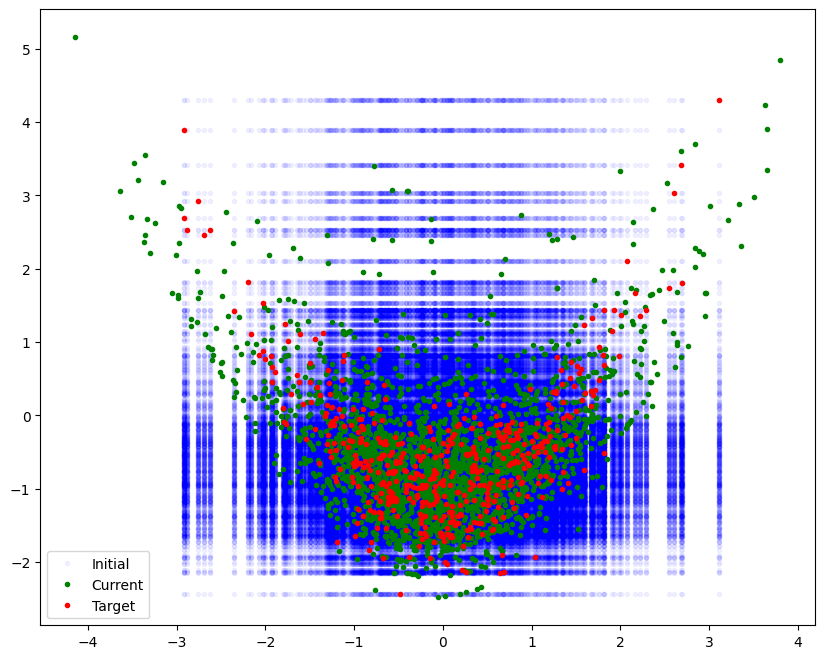

In [ ]:
# plot points
plt.figure(figsize=(10,8))
plt.plot(data_product[:,0], data_product[:,1], '.b', label='Initial',alpha=0.05)
plt.plot(data_flowing[:,0], data_flowing[:,1], '.g', label='Current',alpha=1)
plt.plot(data[:,0], data[:,1], '.r', label='Target',alpha=1)
plt.legend()